<img src="./logo_UTN.svg" align="right" width="150" /> 

#### Teoría de los Circuitos 2

# Tarea semanal 6
#### Autor:Nicolas Trombetta
#### Profesor: Mariano Llamedo Soria

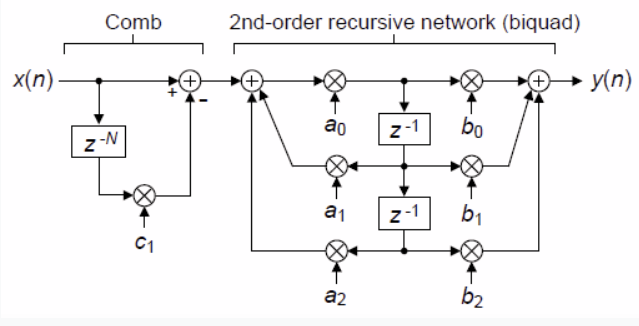

**1)** Comprobar que el esquema se corresponde con la siguiente transferencia:
$$
H(z)=(1-c_1z^{-N})\frac{b_0+b_1z^{-1}+b_2z^{-2}}{\frac{1}{a_0}-a_1z^{-1}-a_2z^{-2}}
$$

Sea $W(z)$ la señal en el nodo que forman la salida del multplicador de $a_0$ y la entrada del multiplicador de $b_0$. Luego se deduce que 
$$
Y(z)=b_0W(z)+b_1W(z)z^{-1}+b_2W(z)z^{-2}
$$
Sacamos factor comun $W(z)$ y obtenemos:
$$
Y(z)=W(z)(b_0+b_1z^{-1}+b_2z^{-2})
$$
Averiguemos ahora la expresion de $W(z)$:
$$
\frac{W(z)}{a_0}=X(z)(1-c_1z^{-N})+a_1W(Z)z^{-1}+a_2W(z)z^{-2}
$$
Acomodando la expresion obtenemos:
$$
W(z)=X(z)\frac{(1-c_1z^{-N})}{\frac{1}{a_0}+a_1z^{-1}+a_2z^{-2}}
$$

Reemplazamos $W(z)$ en la expresion de $Y(z)$ y nos queda que:
$$
Y(z)=X(z)(1-c_1z^{-N})\frac{(b_0+b_1z^{-1}+b_2z^{-2})}{\frac{1}{a_0}+a_1z^{-1}+a_2z^{-2}}
$$
Finalmente comprobamos que:
$$
H(z)=\frac{Y(z)}{X(z)}=(1-c_1z^{-N})\frac{(b_0+b_1z^{-1}+b_2z^{-2})}{\frac{1}{a_0}+a_1z^{-1}+a_2z^{-2}}
$$


**2)** Filtro de media móvil ( moving average ó CIC: cascaded integrator comb )

Verificar la transferencia para $a_0= 1$, $a_1= 1$, $b_0 = 1/𝑁$ ,$c_1= 1$  y $N = 3, 4 ,5$
¿Es un filtro IIR o FIR ? Discuta las ventajas que tendría esta implementación respecto al filtro FIR de media móvil 3. 
¿Podría implementar el siguiente sistema 
 = (1, 1, 1, 1, 1, 1, 1) con esta topología ?

 $$
 H(z)=\frac{1}{N}\frac{1-z^{-N}}{1-z^{-1}}
 $$

 Reacomedando la expresion:
 $$
 H(z)=\frac{1}{N}(\frac{z}{z-1}-z^{-N}\frac{z}{z-1})
 $$

 recordando que $\frac{z}{z-1}$ representa en el dominio temporal a $u[n]$

 $$
 h[n]=\frac{1}{N}(u[n]-u[n-N])
 $$

 A partir de n=N este la respuesta al impulso de este sistema es se anula, por lo tanto es un filtro fir. La ventaja frente al filtro de media movil fir es la cantidad de datos que deben almacenarse. En este filtro solo debe almacenarse el dato $u[n-N]$ mientras que en el filtro de media movil deben almacenarse las N muestras anteriores. 

 Para implementar $h[n]=(1,1,1,1,1,1,1)$, se deberia tomar $N=7$ y sustituir $b_0=1/N$ por $b_0=1$

**3)** Filtro diferenciador ( differentiator ). Obtener los valores de $a_i$ y $b_k$ para obtener  $y(n)=\frac{x(n)-x(n-2)}{2}$ 
Evaluar al sistema con un seno discreto en python y comprobar si la salida se aproxima a la derivada.

Aplicamos la trasformada Z a la ecuacion de diferencias y obtenemos:
$$
Y(z)=X(z)\frac{1-z^{-2}}{2}
$$
$$
H(z)=\frac{Y(z)}{X(z)}=\frac{1-z^{-2}}{2}
$$

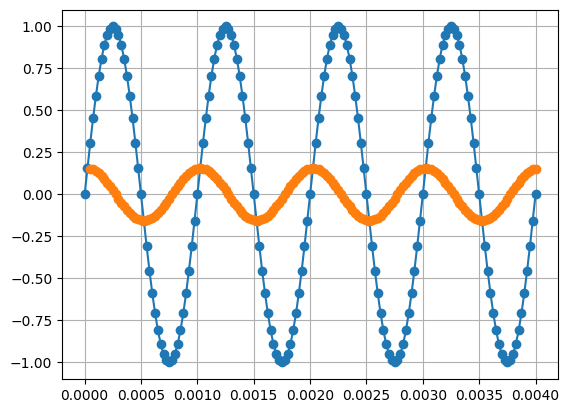

In [3]:
import numpy as np
import matplotlib.pyplot as plt

f=1000
fs=40000
n = np.linspace(0, 4/f, int(4*fs/f)+1)
x=np.sin(2*np.pi*f*n)

y = (x[2:] - x[:-2]) / 2

plt.plot(n, x, "o-")
plt.plot(n[2:],y,"o-")
plt.grid(True)  
plt.show()


**4)** Filtro elimina continua ( DC Blocker )

• Verifique la transferencia para $a_0= 1$, $a_1=\beta$, $b_0= 1$ , $b_1= -1$ para $\beta=0.9$ 

• Determine $\beta$ para que la transferencia en $\Omega=0.1\pi$ sea 3 dB menor a la transferencia en $\Omega=\pi$

$$
H(z)=\frac{1-z^{-1}}{1-\beta z^{-1}}
$$

Reemplazando $z=e^{j\omega}$
$$
H(e^{j\omega})=\frac{1-e^{-j\omega}}{1-\beta e^{-j\omega}}
$$
De donde se obtiene que:
$$
|H(e^{j\omega})|=\frac{2sen(\frac{\omega}{2})}{\sqrt{1-2\beta cos(\omega)+\beta^2}}
$$

Se quiere obtener $\beta$ de forma que:
$$
|H(e^{j0.1\pi})|=\frac{|H(e^{j\pi})|}{\sqrt{2}}
$$
Entonces:
$$
\frac{2sen(\frac{0.1\pi}{2})}{\sqrt{1-2\beta cos(0.1\pi)+\beta^2}}=\frac{\sqrt{2}}{\sqrt{1+2\beta+\beta^2}}
$$

Reacomodando la expresion:
$$
(2 sen(\frac{0.1\pi}{2})-1)+2[2sen(\frac{0.1\pi}{2})+cos(0.1\pi)]\beta+[2sen(\frac{0.1\pi}{2})-1]\beta^2=0
$$

In [36]:
w_1=0.1*np.pi

c=2*np.sin(w_1/2)**2-1
b=2*(2*np.sin(w_1/2)**2+np.cos(w_1))
a=2*np.sin(w_1/2)**2-1

beta=np.roots([a,b,c])

print(beta)

##Verifico resultado
print("beta=",beta[1])
H_01=(1-np.exp(-1j*w_1))/(1-beta[1]*np.exp(-1j*w_1))
print("|H(e^(j0.1pi))|=",np.abs(H_01))
H_pi=(1-np.exp(-1j*np.pi))/(1-beta[1]*np.exp(-1j*np.pi))
print("|H(e^(pi))|=",np.abs(H_pi))

print(np.abs(H_pi)/np.abs(H_01))



[1.37638192 0.72654253]
beta= 0.726542528005361
|H(e^(j0.1pi))|= 0.8191014929744633
|H(e^(pi))|= 1.1583844403245362
1.4142135623730947


**5)** Filtro Peine  ( Comb filter )

• Verifique la transferencia para $c_1$ = -1 y $N=8$  
 
• Proponga una $f_{sampling}$ y halle las frecuencias donde se generan los peaks y los nulls en el espectro.

$$
H(z)=1+z^{-N}
$$
Reemplazando $z=e^{j\omega}$
$$
H(e^{j\omega})=1+e^{-jN\omega}=2e^{-j\omega\frac{N}{2}}cos(\frac{N}{2}\omega)
$$

Entonces los peaks se van a dar cuando $|cos(\frac{N}{2}\omega)|=1$, es decir $\omega=\frac{2k\pi}{N}$
y los nulls cuando $|cos(\frac{N}{2}\omega)|=0$, es decir $\omega=\frac{(2k+1)\pi}{N}$